# Optimal Transport

## Importations and tools functions

### Importations

In [1]:
%pip install sympy
%pip install POT
%pip install boto3


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc
import seaborn as sns
import numpy as np
import ot
import ot.plot
import sklearn.metrics as sme
import matplotlib.pylab as pl
import os

from collections import defaultdict
from types import SimpleNamespace
from scipy.stats import vonmises,ecdf
from scipy.optimize import minimize_scalar
from warnings import warn
from sympy import Interval, Union
from itertools import combinations
from joblib import Parallel, delayed
from statsmodels.stats.multitest import multipletests

In [3]:
import sys
sys.path.append('/home/onyxia/work/torus_test_traduction/')

import stat_s1_python
import sim_null_stat_python
import twosample_test_s1_python

In [4]:
NR = 500

try:
    sim_free_null   
except NameError:
    sim_free_null = sim_null_stat_python.sim_null_stat(NR, NC=2)

In [5]:
bases_list = ["AAA", "AAC", "CAC", "CAA", "CCC", "CCA", "ACC", "ACA"]
angles_list = ['alpha', 'beta', 'gamma', 'delta', 'epsilon', 'zeta']
full_angles_list = ['alpha', 'beta', 'gamma', 'delta', 'epsilon', 'zeta', 'chi', 'nu0', 'nu1', 'nu2', 'nu3', 'nu4']

data_path = "/home/onyxia/work/Data/"
torus_trad_path = "/home/onyxia/work/torus_test_traduction/"

In [6]:
dfs = {}

for base in bases_list:
    dfs[base] = pd.read_csv(f"{data_path}angles_RNA_{base}.csv")

df_all_angles = pd.concat(dfs, axis=1)

In [7]:
mid_angles = {}
first_angles = {}
last_angles = {}

cols_to_drop = ["res_id", "res_name"]

for base in bases_list:
    
    mid_angles[base] = dfs[base][dfs[base]["res_id"].isin([2])].drop(columns=cols_to_drop)
    first_angles[base] = dfs[base][dfs[base]["res_id"].isin([1])].drop(columns=cols_to_drop)
    last_angles[base] = dfs[base][dfs[base]["res_id"].isin([3])].drop(columns=cols_to_drop)

mid_angles["AAA"]

,chain,alpha,beta,gamma,delta,epsilon,zeta,nu0,nu1,nu2,nu3,nu4,eta,theta,chi
1,B,305.490140,162.730043,52.603131,78.995842,214.526967,278.473410,0.070455,336.709644,36.383089,322.671813,23.477230,168.948446,209.995984,189.233622
4,B,146.988674,193.708737,179.793685,81.382929,225.230787,283.202503,8.016439,330.418764,38.904281,324.713641,17.215873,159.669284,195.684487,179.675616
7,B,301.320403,163.375457,50.046480,75.955382,223.673354,292.092174,4.371440,330.290735,42.360514,319.319860,22.886112,163.017130,223.839931,192.378723
10,B,295.578929,176.137498,64.087720,81.199826,209.114531,292.686375,358.939293,337.072121,36.751825,321.620907,24.848753,174.891792,219.747934,184.549837
13,B,301.868572,168.989858,52.243122,80.262432,210.286872,280.323108,0.935298,336.664007,35.627748,323.916667,22.172684,169.729129,208.902042,193.628678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18052,B,359.243083,115.818572,66.577611,83.483783,186.120445,256.786693,7.027008,332.352175,36.700126,326.430947,16.744271,185.351610,221.568289,297.780053
18055,B,143.786438,216.118476,186.337421,148.069144,208.983270,216.610609,338.920824,36.099064,323.462945,25.241961,357.198641,190.847730,170.360477,291.694825
18058,B,40.453015,250.096048,248.807834,147.528139,263.262144,71.416625,339.036145,35.579300,324.210889,24.606173,357.511716,230.553841,16.753732,50.805860
18061,B,160.606135,190.562729,173.702897,91.886990,229.348767,292.482836,17.771124,325.291458,37.452448,331.822386,6.719794,219.537182,209.696504,185.924817


In [8]:
mid_6angles = {}
first_6angles = {}
last_6angles = {}
mid_nu = {}
first_nu = {}
last_nu = {}

for base in bases_list:

    mid_6angles[base] = mid_angles[base][["alpha", "beta", "gamma", "delta", "epsilon", "zeta"]]
    first_6angles[base] = first_angles[base][["alpha", "beta", "gamma", "delta", "epsilon", "zeta"]]
    last_6angles[base] = last_angles[base][["alpha", "beta", "gamma", "delta", "epsilon", "zeta"]]
    
    mid_nu[base] = mid_angles[base][["nu0", "nu1", "nu2", "nu3", "nu4"]]
    first_nu[base] = first_angles[base][["nu0", "nu1", "nu2", "nu3", "nu4"]]
    last_nu[base] = last_angles[base][["nu0", "nu1", "nu2", "nu3", "nu4"]]

### Tool functions

In [68]:
def s3_upload(uploaded_path, uploaded_name, upload_path = "DihedralAnglesStudy/DistanceMatrices/"):

    import boto3, os

    s3 = boto3.client("s3",
                      endpoint_url="https://minio-simple.lab.groupe-genes.fr",
                      aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
                      aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
                      aws_session_token=os.environ["AWS_SESSION_TOKEN"])

    fichier = uploaded_path
    s3.upload_file(fichier, "wbuchy-ensai", f"{upload_path}{uploaded_name}")
    print("Upload done !")

In [9]:
def tore_dist(x, y):
    
    x, y = np.atleast_1d(x), np.atleast_1d(y)
    angle_value = 360.0
    half_val = 180.0
    
    dist_sq = 0.0
    for i in range(len(x)):
        diff = x[i] - y[i]
        short_diff = (diff + half_val) % angle_value - half_val
        dist_sq += short_diff**2
        
    return np.sqrt(dist_sq)

In [10]:
def tore_dist_centred(x, y):
    x, y = np.atleast_1d(x), np.atleast_1d(y)
    diff = x - y
    short_diff = (diff + 0.5) % 1.0 - 0.5
    return np.sqrt(np.sum(short_diff ** 2))

In [11]:
def tore_dist_p(x, y, p, centred = False):
    if(centred == False):
        return(tore_dist(x,y)**p)
    elif(centred == True):
        return(tore_dist_centred(x,y)**p)
    else:
        raise ValueError("Boolean needed for centred")

In [12]:
def quadra_cost(x,y):
    return((x - y)**2)

In [13]:
def eIntegrate(fun, a = 0, b = 1, n = 1000):
    stairs = np.arange(a, b, 1/n)
    stairs = np.append(stairs, b)
    sum_darboux_plus, sum_darboux_minus = 0, 0
    
    for i in range(len(stairs)-1):
        sum_darboux_plus += (stairs[i+1] - stairs[i]) * max(fun(stairs[i+1]), fun(stairs[i]))
        sum_darboux_minus += (stairs[i+1] - stairs[i]) * min(fun(stairs[i+1]), fun(stairs[i]))

    return(np.mean(sum_darboux_plus, sum_darboux_minus))

## Distance calculation

### Distance functions

In [14]:
def bins_generator(mean_val, bins):
    
    if (bins > 180): 
        raise ValueError("Bins cannot be bigger than 180°")

    diffMbins = mean_val - bins
    sumMbins = mean_val + bins
    
    if (diffMbins < 0):
        int1 = Interval(0, mean_val)
        int2 = Interval(diffMbins % 360, 360)
        bound_inf = Union(int1, int2)
        bound_sup = Interval(mean_val, sumMbins)
        return(Union(bound_inf, bound_sup))
        
    elif (sumMbins > 360):
        int1 = Interval(0, sumMbins % 360)
        int2 = Interval(mean_val, 360)
        bound_sup = Union(int1, int2)
        bound_inf = Interval(diffMbins, mean_val)
        return(Union(bound_inf, bound_sup))
        
    else :
        return(Interval(diffMbins,sumMbins))

In [15]:
bins_generator(355,15)

Union(Interval(0, 10), Interval(340, 360))

In [16]:
in_bins = np.vectorize(lambda x: x in bins_generator(305,5))

In [17]:
xs = mid_6angles['AAA'][in_bins(mid_6angles['AAA']["beta"])][["alpha"]].to_numpy()
xt = mid_6angles["AAA"][["alpha"]].to_numpy()

In [18]:
cost_matrix = ot.dist(xs, xt, metric = lambda x, y: tore_dist_p(x, y, 2))

In [19]:
a, b = np.ones(len(xs))/len(xs), np.ones(len(xt))/len(xt)

In [20]:
test = ot.solve(cost_matrix, a, b)

In [21]:
test.plan

array([[0.        , 0.        , 0.00016606, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.00016606, 0.        , ..., 0.        , 0.00016606,
        0.00016606],
       [0.00016606, 0.        , 0.        , ..., 0.00016606, 0.        ,
        0.        ]], shape=(3, 6022))

In [22]:
np.sqrt(test.value)

np.float64(78.43506202247256)

In [23]:
xs = mid_6angles['AAA'][["alpha"]].to_numpy()
xt = mid_6angles["AAA"][["beta"]].to_numpy()
cost_matrix = ot.dist(xs, xt, metric = lambda x, y: tore_dist_p(x, y, 2))
a, b = np.ones(len(xs))/len(xs), np.ones(len(xt))/len(xt)
test = ot.solve(cost_matrix, a, b)
print(test.plan)
np.sqrt(test.value)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


np.float64(72.34202540741859)

In [24]:
dist_max = np.sqrt(2)*180

In [25]:
def w_dist(xs, xt, joined_data_1 = False, joined_data_2 = False, mean_val_1 = 180, mean_val_2 = 180, bins_side_size_1 = 5, bins_side_size_2 = 5, p = 2, a = 'uniform', b = 'uniform'):
    
    in_bins_1 = np.vectorize(lambda x: x in bins_generator(mean_val_1, bins_side_size_1))
    in_bins_2 = np.vectorize(lambda x: x in bins_generator(mean_val_2, bins_side_size_2))

    xs_masked, xt_masked = xs[in_bins_1(xs)].to_numpy(), xt[in_bins_2(xt)].to_numpy()


    if not isinstance(joined_data_1, bool):
        mask1 = in_bins_1(joined_data_1)
        if mask1.sum() == 0:
            raise ValueError("No points in the bins of the first dimension")
        xs_masked = xs[mask1].to_numpy()
        
    if not isinstance(joined_data_2, bool):
        mask2 = in_bins_2(joined_data_2)
        if mask2.sum() == 0:
            raise ValueError("No points in the bins of the second dimension")
        xt_masked = xt[mask2].to_numpy()
    
    if len(xs_masked) == 0 or len(xt_masked) == 0:
        raise ValueError("No points in the bins")

    if (a == 'uniform'):
        a = np.ones(len(xs_masked))/len(xs_masked)

    if (b == 'uniform'):
        b = np.ones(len(xt_masked))/len(xt_masked)

        
    solved = ot.solve_sample(X_a = xs_masked, X_b = xt_masked, a = a, b = b, metric = lambda x, y: tore_dist_p(x, y, p))

    pvalue = twosample_test_s1_python.twosample_test_s1(xs_masked.flatten()/360, xt_masked.flatten()/360, sim_free_null).pvalue


    return SimpleNamespace(plan = solved.plan, value = solved.value**(1/p), pvalue = pvalue)

In [26]:
#testing_fun = w_dist(xs = mid_6angles["AAA"][["alpha"]], xt = mid_6angles["AAA"][["alpha"]], joined_data_1 = mid_6angles['AAA']["zeta"], mean_val_1 = 305, bins_side_size_2 = 179)

In [27]:
def optimized_w_dist(xs, xt, p = 2, n = 1000):

    xs, xt = xs.to_numpy().flatten(), xt.to_numpy().flatten()
    centred_xs, centred_xt = xs/360, xt/360

    Fxs = ecdf(centred_xs)
    Fxt = ecdf(centred_xt)

    def inv_Fxs(s):
        bounds = (0, s)
        return(minimize_scalar(Fxs.cdf.evaluate, bounds = bounds, method = "Bounded"))

    def inv_Fxt(s):
        bounds = (0, s)
        return(minimize_scalar(Fxt.cdf.evaluate, bounds = bounds, method = "Bounded"))

    def darboux_integral(alpha):
        def optimized(u):
            return tore_dist_p(inv_Fxs(u).x, inv_Fxt((u - alpha) % 1).x, p=p)

        stairs = np.linspace(0, 1, n + 1)
        sum_plus, sum_minus = 0, 0

        for i in range(len(stairs) - 1):
            h = stairs[i + 1] - stairs[i]
            vals = optimized(stairs[i + 1]), optimized(stairs[i])
            sum_plus  += h * max(vals)
            sum_minus += h * min(vals)

        return np.mean([sum_minus, sum_plus])

    result = minimize_scalar(darboux_integral, bounds=(0, 1), method="Bounded")

    return SimpleNamespace(x_value = result.x, value = result.fun)

In [28]:
#optimized_w_dist(mid_6angles["AAA"][["alpha"]], mid_6angles["AAA"][["beta"]]).value

In [29]:
def w_dist_conditional_y(X, Y, y_center, bins_side_size = 5, p = 2, n_min = 30):

    interval = bins_generator(y_center, bins_side_size)
    mask = np.array([y in interval for y in Y])

    X_conditional = X[mask].to_numpy().reshape(-1, 1)
    X_full = X.to_numpy().reshape(-1, 1)

    if len(X_conditional) < n_min :
        return SimpleNamespace(value=np.nan, pvalue=np.nan, plan=None, statistic = np.nan)

    a = np.ones(len(X_conditional)) / len(X_conditional)
    b = np.ones(len(X_full)) / len(X_full)

    solved = ot.solve_sample(
        X_a=X_conditional,
        X_b=X_full,
        a=a, b=b,
        metric=lambda x, y: tore_dist_p(x, y, p)
    )

    testing = twosample_test_s1_python.twosample_test_s1(X_full.flatten()/360, X_conditional.flatten()/360, sim_free_null)

    return SimpleNamespace(plan = solved.plan, value = solved.value**(1/p), pvalue = testing.pvalue, statistic = testing.stat)

### Experimentations for the $\mathbb{S}^1$ tests

In [30]:
stock_exp = {}
for i in range(1000):
    x, y = np.random.rand(100), np.random.rand(100)
    stock_exp[i] = twosample_test_s1_python.twosample_test_s1(x, y, sim_free_null).pvalue

stock_exp = np.array(list(stock_exp.values()))

Text(0.5, 1.0, 'pvalues of the 1000 two 100-samples tests on $\\mathbb{S}^1$')

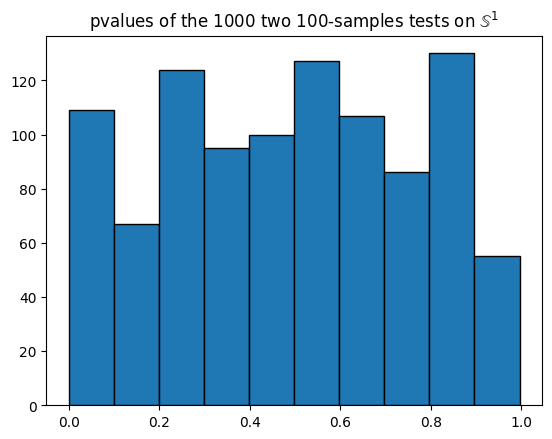

In [31]:
plt.hist(stock_exp, edgecolor = 'black')
plt.title(r"pvalues of the 1000 two 100-samples tests on $\mathbb{S}^1$")

Text(0.5, 1.0, 'p-values eCDF of the 1000 two 100-samples tests on $\\mathbb{S}^1$')

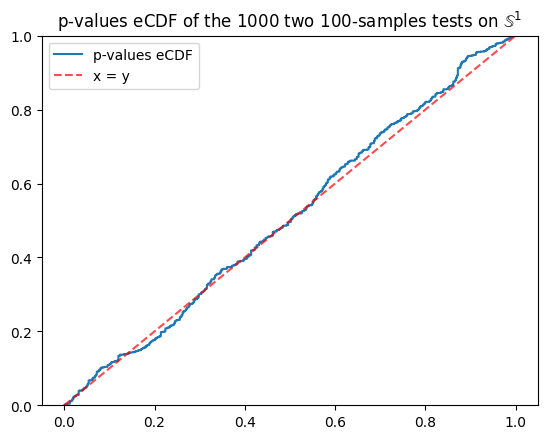

In [32]:
plt.ecdf(stock_exp)
time = np.arange(0,1,.001)
plt.plot(time,time, linestyle = '--', alpha = .7, color = 'red')
plt.legend(['p-values eCDF', 'x = y'])
plt.title(r"p-values eCDF of the 1000 two 100-samples tests on $\mathbb{S}^1$")

### Tests on the real data

In [33]:
def w_dist_conditional_y_graph_uni(X_angle_name, base, bins_side_size=5, p=2):

    X = mid_6angles[base][X_angle_name]
    y_centers = np.arange(0, 360, bins_side_size)

    fig, ax = plt.subplots(figsize=(10, 6))
    for angle_name in [k for k in mid_6angles[base].keys() if k != X_angle_name]:
        Y = mid_6angles[base][angle_name]
        distances = Parallel(n_jobs=-1)(
            delayed(w_dist_conditional_y)(X, Y, y, bins_side_size, p=p) 
            for y in y_centers
        )
        ax.plot(y_centers, [d.value for d in distances], label=angle_name)

    ax.set_xlabel("Y (dihedral angle)")
    ax.set_ylabel(f"W( P({X_angle_name}|Y=y), P({X_angle_name}) )")
    ax.set_title(f"Conditionnal Wasserstein - {base}")
    ax.legend()

    plt.tight_layout()
    plt.show()

In [34]:
#w_dist_conditional_y_graph_uni('alpha','AAA')

In [35]:
def w_dist_conditional_y_graph(X_angle_name, bins_side_size=5, p=2):
    y_centers = np.arange(0, 360, bins_side_size)
    fig, axes = plt.subplots(2, 4, figsize=(24, 15))
    axes = axes.flatten()

    for i, base in enumerate(bases_list):
        X = mid_6angles[base][X_angle_name]        
        for angle_name in [k for k in mid_6angles[base].keys() if k != X_angle_name]:
            Y = mid_6angles[base][angle_name]

            distances = Parallel(n_jobs=-1)(
                delayed(w_dist_conditional_y)(X, Y, y, bins_side_size, p=p)
                for y in y_centers
            )
            axes[i].plot(y_centers, [d.value for d in distances], label=angle_name)
            
        axes[i].set_xlabel("Y (dihedral angles)")
        axes[i].set_ylabel(f"W( P({X_angle_name}|Y=y), P({X_angle_name}) )")
        axes[i].set_title(f"Conditionnal Wasserstein - {base}")
        axes[i].legend()    

    plt.suptitle(f'Wasserstein distance for the angle {X_angle_name}')
    plt.tight_layout()
    plt.show()

In [36]:
#w_dist_conditional_y_graph('alpha')

In [44]:
# def calc_and_save(base, X_angle, Y_angle):
#     save_path = f'wasserstein_results/{base}_{X_angle}_{Y_angle}_distance.npy'
    
#     if os.path.exists(save_path):
#         print(f"  [SKIP] {base} | {X_angle} vs {Y_angle} déjà calculé")
#         return
    
#     print(f"  [START] {base} | {X_angle} vs {Y_angle}")
    
#     X = mid_angles[base][X_angle]
#     Y = mid_angles[base][Y_angle]
    
#     results = [w_dist_conditional_y(X, Y, y, bins_side_size=5) for y in y_centers]
    
#     data = np.array([
#         [r.value, r.pvalue, r.statistic] for r in results
#     ])  # shape (72, 3)
    
#     np.save(save_path, data)
#     print(f"  [DONE] {base} | {X_angle} vs {Y_angle} -> {save_path}")

# def load_results(base, X_angle):
#     other_angles = [a for a in full_angles_list if a != X_angle]
#     dfs = {}
    
#     for Y_angle in other_angles:
#         path = f'/home/onyxia/work//DihedralAnglesStudy/wasserstein_results/{base}_{X_angle}_{Y_angle}_distance.npy'
#         data = np.load(path)
#         dfs[Y_angle] = pd.DataFrame(
#             data,
#             index=y_centers,
#             columns=[f'distance_{Y_angle}', f'pvalue_{Y_angle}', f'statistic_{Y_angle}']
#         )
    
#     return pd.concat(dfs.values(), axis=1)

In [45]:
# os.makedirs('wasserstein_results', exist_ok=True)
# y_centers = np.arange(0, 360, 5)

# combos = [
#     (base, X_angle, Y_angle)
#     for base in bases_list
#     for X_angle in full_angles_list
#     for Y_angle in [a for a in full_angles_list if a != X_angle]
# ]

# print(f"Total : {len(combos)} combinaisons ({len(combos) * 72} appels OT)")

# Parallel(n_jobs=-1, backend='threading')(
#     delayed(calc_and_save)(base, X_angle, Y_angle)
#     for base, X_angle, Y_angle in combos
# )

# print("Terminé.")

In [46]:
wasserstein = {}

for X_angle in full_angles_list:
    wasserstein[X_angle] = {}
    for base in bases_list:
        wasserstein[X_angle][base] = load_results(base, X_angle)

for X_angle in full_angles_list:
    pvalues_cols = [f"pvalue_{Y_angle}" for Y_angle in full_angles_list if Y_angle != X_angle]
    adjusted_pvalues_cols = [f"adjusted_pvalue_{Y_angle}" for Y_angle in full_angles_list if Y_angle != X_angle]
    for base in bases_list:
        df = wasserstein[X_angle][base][pvalues_cols]

        original_shape = df.shape
        original_index = df.index
        original_columns = df.columns

        pvals_flat = df.to_numpy().flatten()
        corrected = multipletests(pvals=pvals_flat, method='bonferroni')[1]

        corrected_df = pd.DataFrame(corrected.reshape(original_shape),
                                    index=original_index,
                                    columns=original_columns)

        wasserstein[X_angle][base][adjusted_pvalues_cols] = corrected_df
            
np.save('/home/onyxia/work/Data/full_Wasserstein_distances', wasserstein)

wasserstein = np.load(f'{data_path}/full_Wasserstein_distances.npy', allow_pickle=True).item()

In [47]:
keeped_H0 = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int))))

for X_angle in full_angles_list:
    for base in bases_list:
        for Y_angle in full_angles_list:
            if Y_angle == X_angle:
                continue
            for bins in range(0, 360, 5):
                adjusted_pval = wasserstein[X_angle][base][f"adjusted_pvalue_{Y_angle}"][bins]
                keeped_H0[X_angle][base][f"statistic_{Y_angle}"][bins] = 1 if adjusted_pval > .05 else 0

In [50]:
def rep_wass_mono_angle(X_angle, representation="distance", alpha=False, change_type_line=False):

    representation_list = ["distance", "pvalue", "statistic", "adjusted_pvalue"]
    if X_angle not in full_angles_list:
        raise ValueError(f"X_angle has to be in {full_angles_list}")
    if representation not in representation_list:
        raise ValueError(f"representation has to be in {representation_list}")   

    fig, axes = plt.subplots(2, 4, figsize=(20, 13))
    axes = axes.flatten()

    for i, base in enumerate(bases_list):
        for Y_angle in [a for a in full_angles_list if a != X_angle]:
            y_values = wasserstein[X_angle][base][f"{representation}_{Y_angle}"]            

            if representation == "statistic" and X_angle in keeped_H0 and base in keeped_H0[X_angle] and f"statistic_{Y_angle}" in keeped_H0[X_angle][base]:

                h0_values = keeped_H0[X_angle][base][f"statistic_{Y_angle}"]
                x_values = y_values.index

                segments = []
                current_style = None
                seg_x, seg_y = [], []

                for x, y in zip(x_values, y_values):
                    h0 = h0_values.get(x, 0)
                    style = ["-", 1] if h0 == 0 else ["--", 0.6]

                    if current_style is None or style[0] != current_style[0]:
                        if seg_x:
                            segments.append((seg_x, seg_y, current_style[0], current_style[1]))
                        seg_x, seg_y = [x], [y]
                        current_style = style

                    else:
                        seg_x.append(x)
                        seg_y.append(y)
                        
                if seg_x:
                    segments.append((seg_x, seg_y, current_style[0], current_style[1]))

                color = None
                for j, (sx, sy, st, sa) in enumerate(segments):

                    if j == 0:
                        ghost, = axes[i].plot([], [], linestyle="-", color=color if color else "C0", label=f"{Y_angle}")
                        line, = axes[i].plot(sx, sy, linestyle=st, alpha=sa)
                        color = line.get_color()
                        ghost.set_color(color)
                    else:
                        axes[i].plot(sx, sy, linestyle=st, alpha=sa, color=color)

            else:
                axes[i].plot(y_values, label=f"{Y_angle}")

        if isinstance(alpha, (int, float)) and not isinstance(alpha, bool):
            axes[i].axhline(alpha, color="black", linestyle="--",
                            label=f"{round(alpha, 3)} threshold")

        axes[i].set_xlabel("Y (dihedral angles)")
        axes[i].set_ylabel(f"{representation}")
        axes[i].set_title(f"Conditionnal Wasserstein - {base}")
        handles, labels = axes[i].get_legend_handles_labels()

        filtered = [(h, l) for h, l in zip(handles, labels) if h.get_linestyle() == "-"]
        if filtered:
            handles_f, labels_f = zip(*filtered)
            axes[i].legend(handles_f, labels_f)
        else:
            axes[i].legend()   

    plt.suptitle(f'{representation}s for the angle {X_angle}')
    plt.tight_layout()
    plt.show()

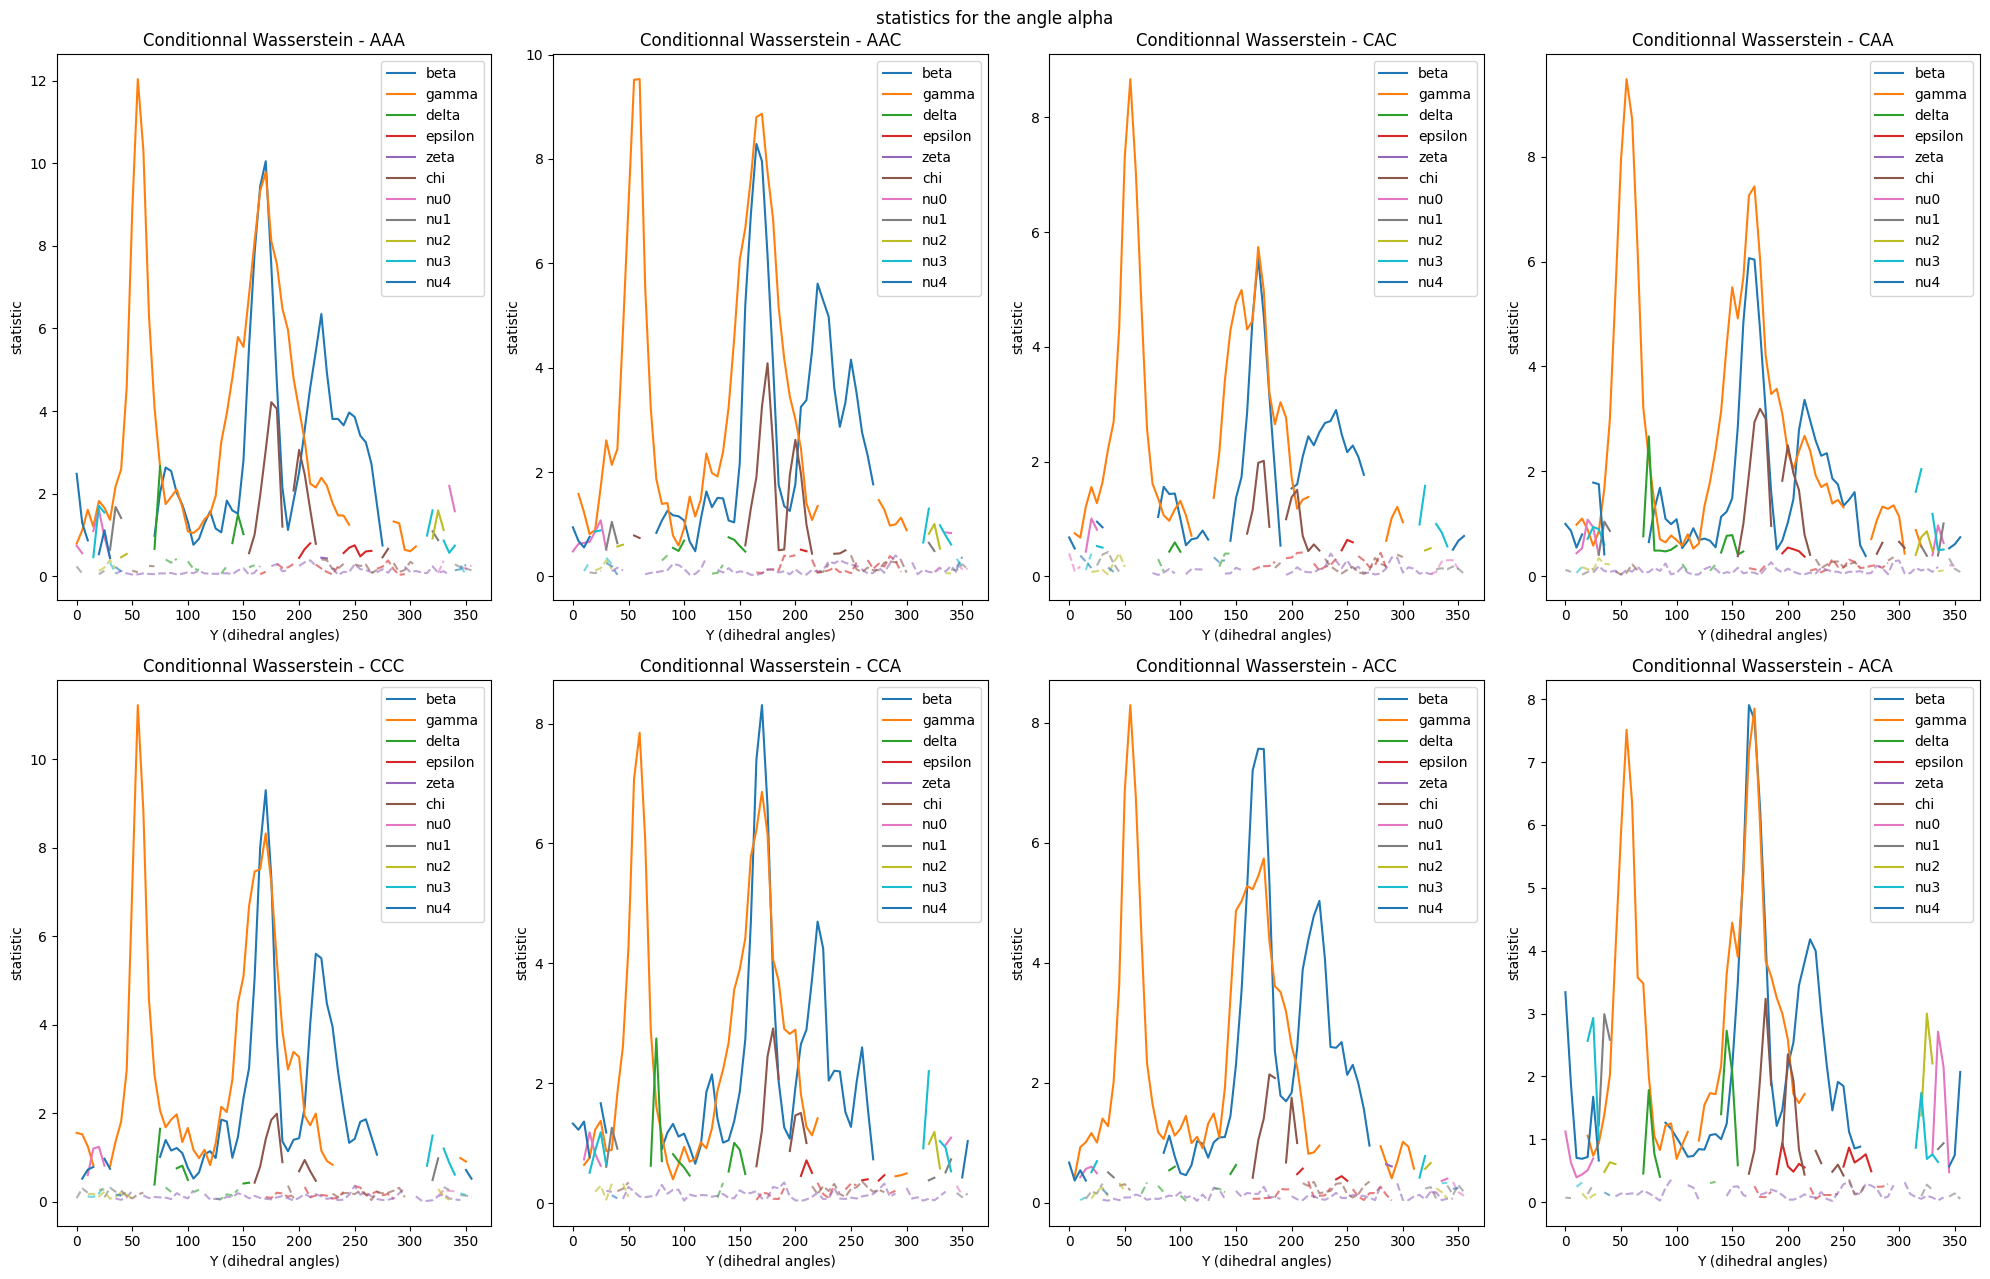

In [51]:
rep_wass_mono_angle(X_angle = "alpha", representation = "statistic", change_type_line = True)

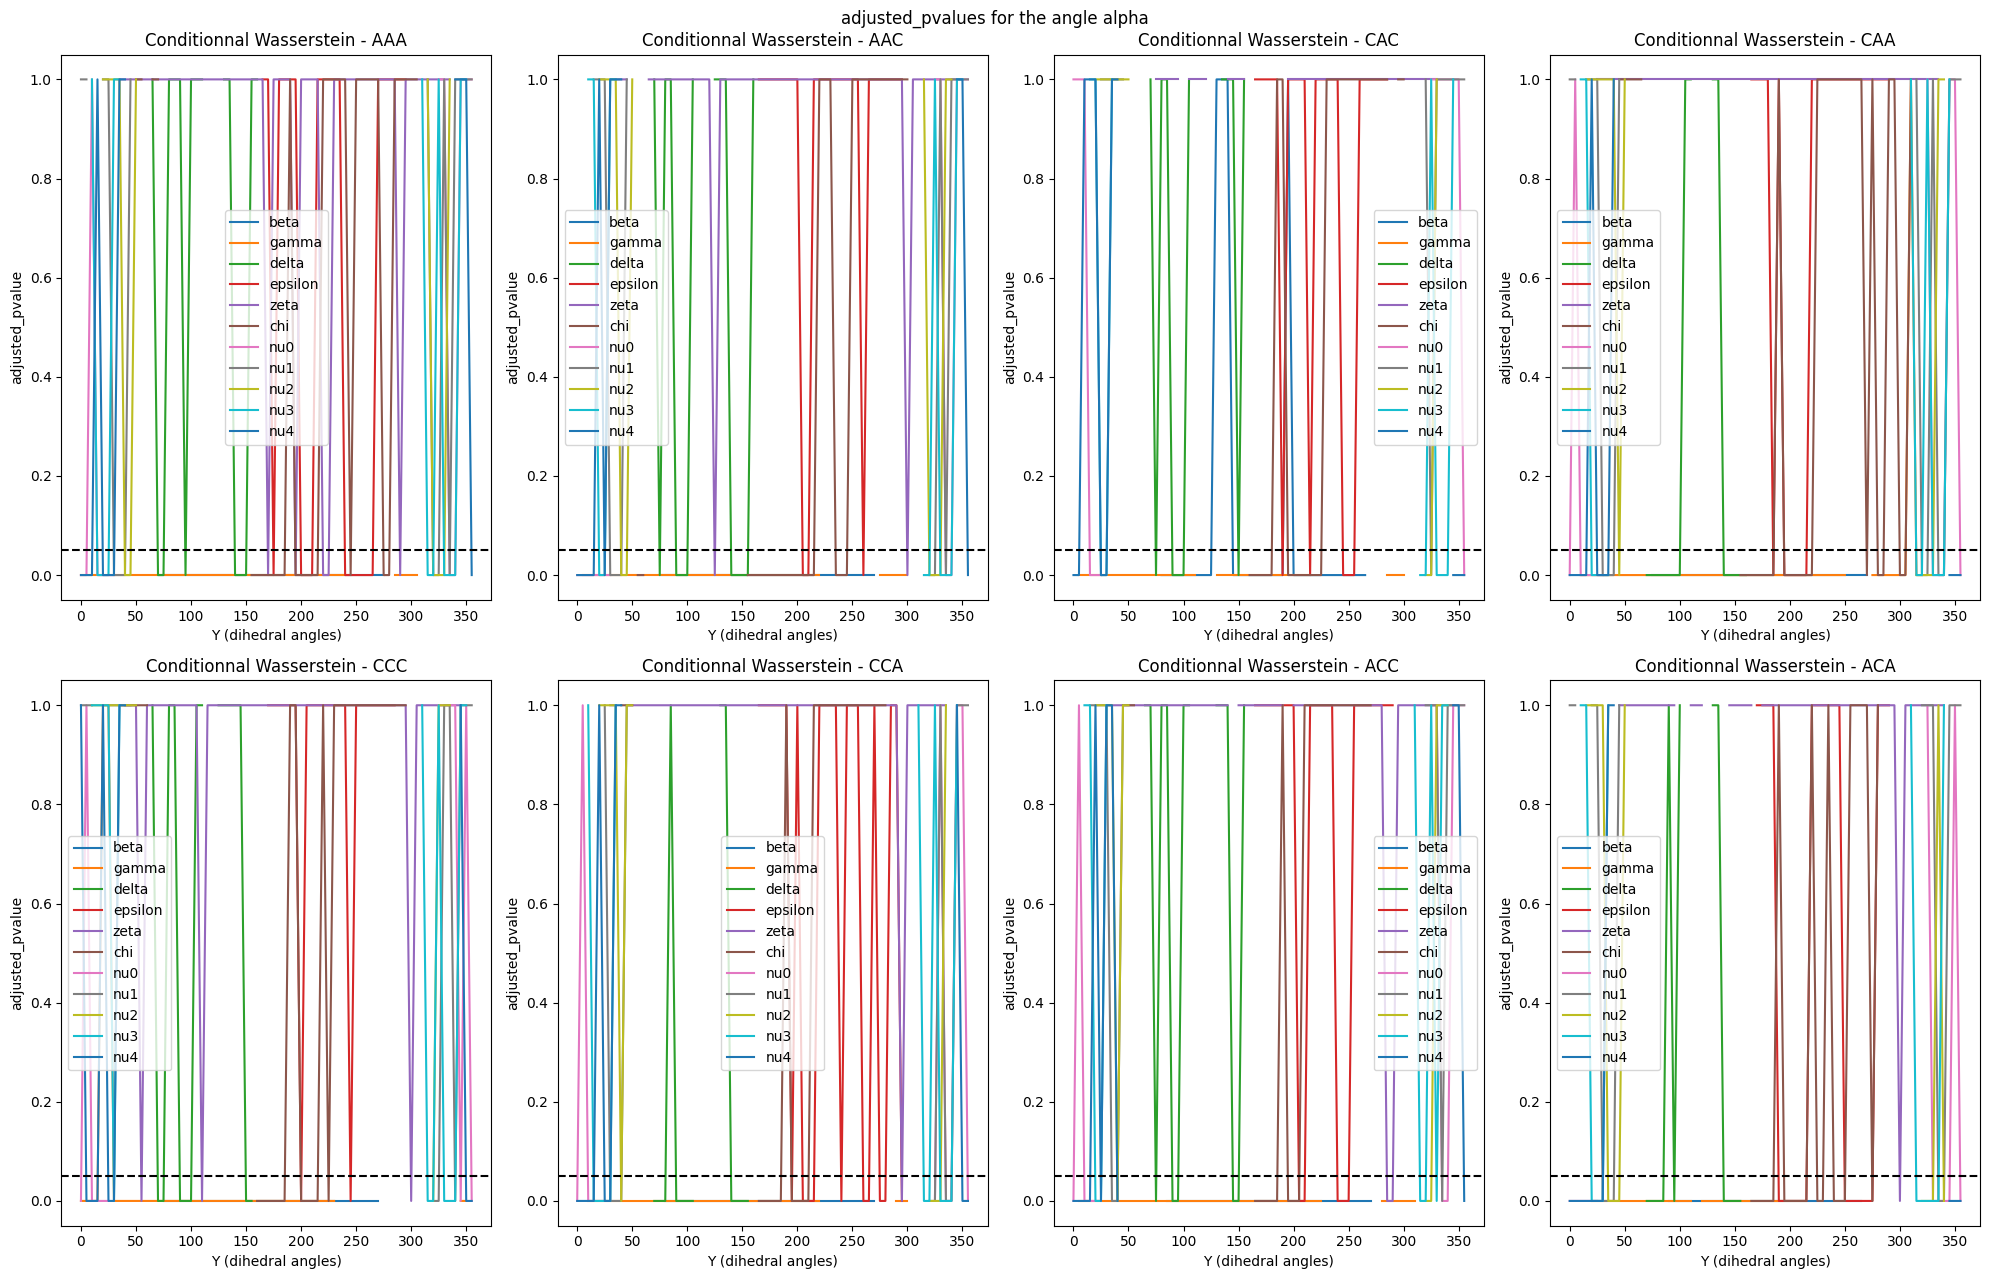

In [52]:
rep_wass_mono_angle(X_angle = "alpha", representation = "adjusted_pvalue", alpha = 0.05)

In [59]:
def global_pvals(angles, base):
    X_angle, Y_angle = angles

    Y = mid_angles[base][Y_angle]
    obj = wasserstein[X_angle][base][f"statistic_{Y_angle}"]

    bin_counts = pd.Series({
        b: ((Y >= b) & (Y < b + 5)).sum()
        for b in obj.index
    })
    
    mean_stat = (obj*bin_counts).sum()/len(Y)
    out_val = np.mean(sim_free_null >= mean_stat)

    return(out_val)

In [60]:
global_pvals_stock = {}
for base in bases_list:
    global_pvals_stock[base] = {pair: global_pvals(pair, base=base) 
        for pair in combinations(full_angles_list, 2)}
    
for base in bases_list:
    matrix = pd.DataFrame(
        index=full_angles_list,
        columns=full_angles_list,
        dtype=float
    )

    for (X_angle, Y_angle), pval in global_pvals_stock[base].items():
        matrix.loc[X_angle, Y_angle] = pval

    flat = matrix.to_numpy().flatten()
    nan_mask = np.isnan(flat)
    corrected = np.full(len(flat), np.nan)
    corrected[~nan_mask] = multipletests(pvals=flat[~nan_mask], method='bonferroni')[1]
    
    corrected_df = pd.DataFrame(
        corrected.reshape(matrix.shape),
        index=matrix.index,
        columns=matrix.columns
    )

    global_pvals_stock[base] = corrected_df

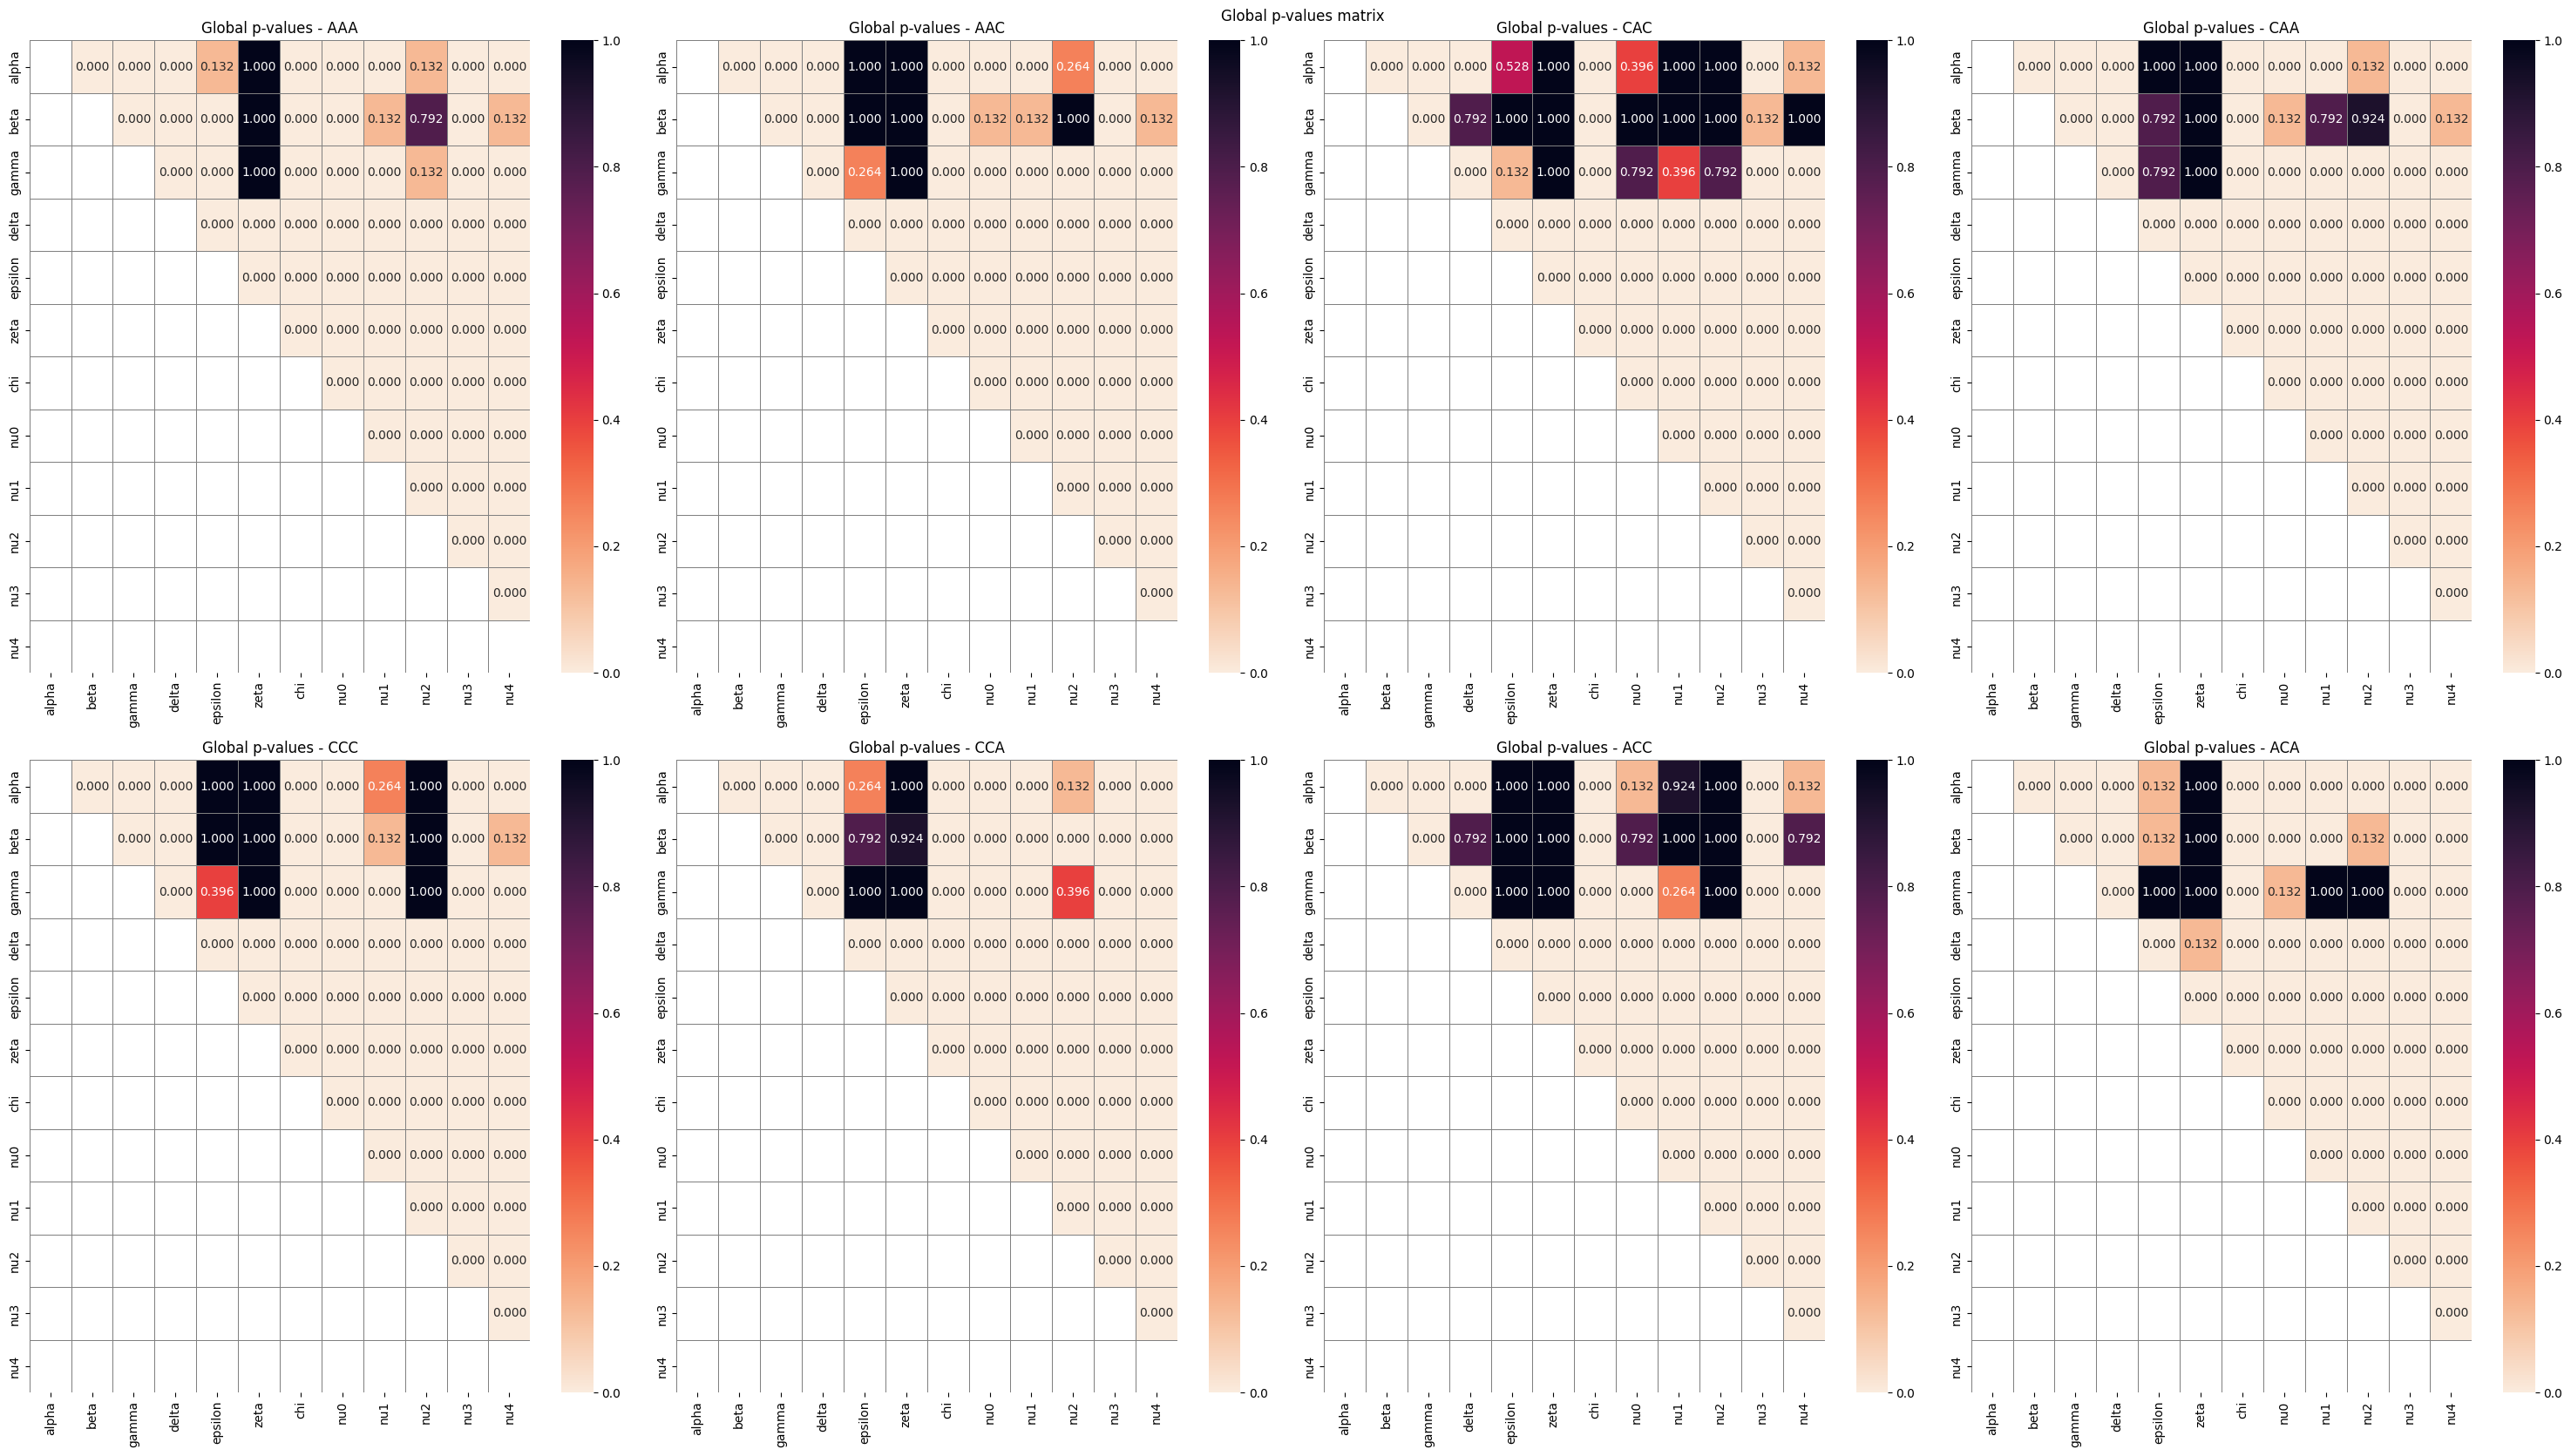

In [81]:
fig, axes = plt.subplots(2, 4, figsize=(30, 17))
axes = axes.flatten()

for i, base in enumerate(bases_list):
    sns.heatmap(
        global_pvals_stock[base].astype(float),
        ax=axes[i],
        annot=True,
        fmt=".3f",
        cmap="rocket_r",
        vmin=0, vmax=1,
        linewidth=.5,
        linecolor="grey" 
    )

    axes[i].set_title(f"Global p-values - {base}")
    
plt.suptitle("Global p-values matrix")
plt.tight_layout()
plt.show()

### Analysis of all the angles